# 📈 Week 2 — Cleaning, Visualization & EDA

Welcome to Week 2!

This week, we’ll move beyond simply collecting stock data and start understanding it through cleaning, visualization, and exploratory data analysis (EDA).

We’ll explore:
- stock price trends
- trading volume
- moving averages
- daily returns
- correlations between features

By the end of this week, you'll be able to analyze stock market behavior visually and derive meaningful insights from data 🚀

## 1 · Pandas — Going Deeper

> ✅ **Reminder from Week 1:** You already know `head()`, `tail()`, `shape`, and selecting a column. This week we go one level deeper.

### Why This Matters
In Week 1 you treated your DataFrame like a display screen — you just printed things. This week you'll treat it like a workbench — selecting specific rows, filtering data, and doing calculations across entire columns at once.


### 1.1 — Quick Recap + Setup


In [26]:
import yfinance as yf
import pandas as pd

# Download 2 years of Apple data
df = yf.download("AAPL", period="2y")

# Flatten multi-level columns if they appear (yfinance sometimes does this)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(df.shape)   # (rows, columns)
print(df.head())


[*********************100%***********************]  1 of 1 completed

(501, 5)
Price            Close        High         Low        Open    Volume
Date                                                                
2024-05-23  185.275070  189.359683  185.027217  189.339850  51005900
2024-05-24  188.348434  188.943288  186.425093  187.198408  36327000
2024-05-28  188.358353  191.342497  187.475997  189.865288  52280100
2024-05-29  188.655792  190.598967  187.882492  187.981639  53068000
2024-05-30  189.647202  190.529558  188.992881  189.121754  49889100


> 💡 **What is `df`?** Just a variable name — short for DataFrame. You'll see it everywhere. You can call it anything (`data`, `stock`, etc.) but `df` is the convention.


### 1.2 — Selecting Columns


In [27]:
# Select one column → gives you a Series (a single list with an index)
close_prices = df["Close"]
print(type(close_prices))   # <class 'pandas.core.series.Series'>
print(close_prices.head())

# Select multiple columns → gives you a smaller DataFrame
ohlc = df[["Open", "High", "Low", "Close"]]
print(ohlc.head())


<class 'pandas.core.series.Series'>
Date
2024-05-23    185.275070
2024-05-24    188.348434
2024-05-28    188.358353
2024-05-29    188.655792
2024-05-30    189.647202
Name: Close, dtype: float64
Price             Open        High         Low       Close
Date                                                      
2024-05-23  189.339850  189.359683  185.027217  185.275070
2024-05-24  187.198408  188.943288  186.425093  188.348434
2024-05-28  189.865288  191.342497  187.475997  188.358353
2024-05-29  187.981639  190.598967  187.882492  188.655792
2024-05-30  189.121754  190.529558  188.992881  189.647202


### 1.3 — Basic Column Math


In [28]:
# You can do math on entire columns at once — no for loops needed

# How much did the price move each day? (High - Low)
df["Daily_Range"] = df["High"] - df["Low"]

# What was the % change from open to close?
df["OC_Change"] = (df["Close"] - df["Open"]) / df["Open"] * 100

print(df[["Open", "Close", "Daily_Range", "OC_Change"]].head())


Price             Open       Close  Daily_Range  OC_Change
Date                                                      
2024-05-23  189.339850  185.275070     4.332465  -2.146817
2024-05-24  187.198408  188.348434     2.518195   0.614336
2024-05-28  189.865288  188.358353     3.866500  -0.793687
2024-05-29  187.981639  188.655792     2.716474   0.358627
2024-05-30  189.121754  189.647202     1.536677   0.277835


### 1.4 — Filtering Rows


In [29]:
# Show only days where price went up (Close > Open)
up_days = df[df["Close"] > df["Open"]]
print(f"Up days: {len(up_days)} out of {len(df)}")

# Show only days where volume was unusually high
high_volume = df[df["Volume"] > df["Volume"].mean() * 1.5]
print(f"High volume days: {len(high_volume)}")
print(high_volume[["Close", "Volume"]].head())


Up days: 276 out of 501
High volume days: 48
Price            Close     Volume
Date                             
2024-06-10  191.461472   97010200
2024-06-11  205.371002  172373300
2024-06-12  211.240158  198134300
2024-06-13  212.400085   97862700
2024-06-17  214.809219   93728300


### 1.5 — Useful Pandas Commands You'll Use Every Week


In [30]:
print(df.describe())                                          # summary stats
print(df.dtypes)                                              # column types
print(df.isnull().sum())                                      # missing values
print(df.sort_values("Volume", ascending=False).head())       # sort by column
print(df.index)                                               # check date index


Price       Close        High         Low        Open        Volume  \
count  501.000000  501.000000  501.000000  501.000000  5.010000e+02   
mean   235.781361  238.110514  233.201224  235.507501  5.287187e+07   
std     26.461423   26.411939   26.443335   26.436300  2.655847e+07   
min    171.513763  188.943288  168.320644  171.046219  1.791060e+07   
25%    215.622177  217.610176  212.776815  214.814992  3.944620e+07   
50%    231.266357  232.586474  228.261629  230.646387  4.650800e+07   
75%    257.292084  258.531784  254.330493  256.550893  5.582420e+07   
max    308.820007  311.399994  305.839996  306.119995  3.186799e+08   

Price  Daily_Range   OC_Change  
count   501.000000  501.000000  
mean      4.909290    0.129400  
std       2.684684    1.541686  
min       1.536677   -7.648634  
25%       3.305225   -0.582452  
50%       4.327560    0.125090  
75%       5.644036    0.782147  
max      28.569047   15.644088  
Price
Close          float64
High           float64
Low        

> 🔍 **`describe()` is your best friend.** Run it on every new dataset. It shows you min, max, mean, and std for every column in one line.


### 🎯 Mini Exercise
Answer these in a comment below:
- How many rows does your 2-year AAPL dataset have?
- What is the average closing price?
- What was the single highest volume day?


In [31]:
# Your answers here:


### 📚 Resources
- 📘 [Kaggle Pandas micro-course — free, 4 hours](https://www.kaggle.com/learn/pandas)
- 🎥 [Pandas tutorial — Corey Schafer (YouTube)](https://www.youtube.com/watch?v=ZyhVh-qRZPA)
- 📖 [Pandas docs — 10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)


---
## 2 · Cleaning Your Dataset

### Why This Matters
Real financial data is never perfect. Yahoo Finance occasionally has missing rows, duplicate entries, or timezone-formatted dates that silently break your code later. Cleaning now saves hours of confusion in Weeks 4–7.


### 2.1 — Check for Missing Values


In [32]:
# Always do this first on any new dataset
print(df.isnull().sum())

# See which rows specifically have missing values
print(df[df.isnull().any(axis=1)])


Price
Close          0
High           0
Low            0
Open           0
Volume         0
Daily_Range    0
OC_Change      0
dtype: int64
Empty DataFrame
Columns: [Close, High, Low, Open, Volume, Daily_Range, OC_Change]
Index: []


> 💡 **Why does missing data happen in stock data?**
> - Market holidays — exchange is closed, no trading happened
> - API glitches — Yahoo Finance occasionally has gaps
> - Stocks that were newly listed or suspended on certain days


### 2.2 — How to Handle Missing Values


In [33]:
# Strategy 1: Drop rows with missing values
# Use when: very few rows are missing (< 1% of data)
df_dropped = df.dropna()
print(f"Rows before: {len(df)} | After dropping NaN: {len(df_dropped)}")

# Strategy 2: Forward fill — carry the last known value forward
# Use when: time series data where you want continuity
df_ffill = df.ffill()
# If Monday's close is missing, it gets filled with Friday's close

# Strategy 3: Fill with a specific value
# Use when: volume is missing (assume 0 = no trading that day)
df["Volume"] = df["Volume"].fillna(0)


Rows before: 501 | After dropping NaN: 501


> ⚠️ **For stock prices, forward fill is almost always the right choice.** Never fill price data with the mean — that mixes future and past information, which will corrupt your model later.


### 2.3 — Remove Columns You Don't Need


In [34]:
# for expmple if you want to drop the "Dividends" and "Stock Splits" columns if they exist, you can do:
# for our dataset we dont have these columns but this is how you would do it in general
cols_to_drop = [c for c in ["Dividends", "Stock Splits"] if c in df.columns]
df = df.drop(columns=cols_to_drop)
print("Cleaned columns:", df.columns.tolist())


Cleaned columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Range', 'OC_Change']


### 2.4 — Check for Duplicates


In [35]:
print(f"Duplicate rows: {df.index.duplicated().sum()}")
df = df[~df.index.duplicated(keep="last")]


Duplicate rows: 0


### 2.5 — Save Your Cleaned Data


In [36]:
import os
os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/AAPL_clean.csv")
print("Saved!")

# Load it back any time without re-downloading
df = pd.read_csv("data/processed/AAPL_clean.csv", index_col="Date", parse_dates=True)


Saved!


### 🚨 Common Mistakes
- **Dropping NaN rows without checking how many** — you might silently lose a big chunk of data
- **`fillna(0)` on price columns** — a price of $0 means the company went bankrupt, not that data is missing
- **Not saving the cleaned file** — forces you to re-run everything from scratch each session

### 🎯 Mini Exercise
Download 2 years of any stock. Run the full cleaning pipeline. Print rows before, NaN count, and rows after cleaning.


---
## 3 · Visualizing Stock Trends

> 💡 **Two libraries you're about to meet:**
> - **Matplotlib** — the foundational chart-drawing library. Think of it like MS Paint for graphs — you control everything.
> - **Seaborn** — built on top of Matplotlib. Better-looking defaults, fewer lines of code for common chart types.
>
> You'll use both. Matplotlib for time series line charts, Seaborn for distributions and heatmaps.

matplot lib resouces : 
https://www.youtube.com/watch?v=7Lc2AxiM17o

https://matplotlib.org/stable/index.html

seaborn : https://seaborn.pydata.org/tutorial/introduction.html



In [37]:
# Run this once in terminal to install
# pip install matplotlib seaborn


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

### 3.1 — Your First Real Stock Chart


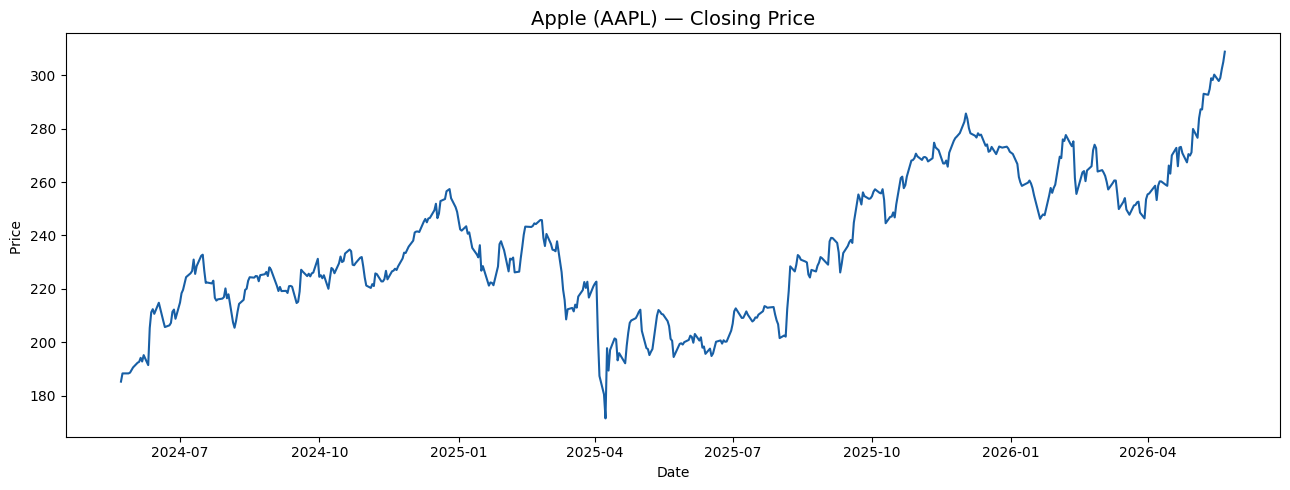

In [39]:
plt.figure(figsize=(13, 5))
plt.plot(df.index, df["Close"], linewidth=1.5, color="#185FA5")
plt.title("Apple (AAPL) — Closing Price", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price ")
plt.tight_layout()
plt.show()


### Notice
Observe the overall long-term direction of the stock. Notice periods where the stock moves smoothly versus periods with sharp fluctuations.

> ⚠️ **Always call `savefig()` BEFORE `show()`** — `show()` clears the canvas and you'll save a blank image.


### 3.2 — Price + Volume Together


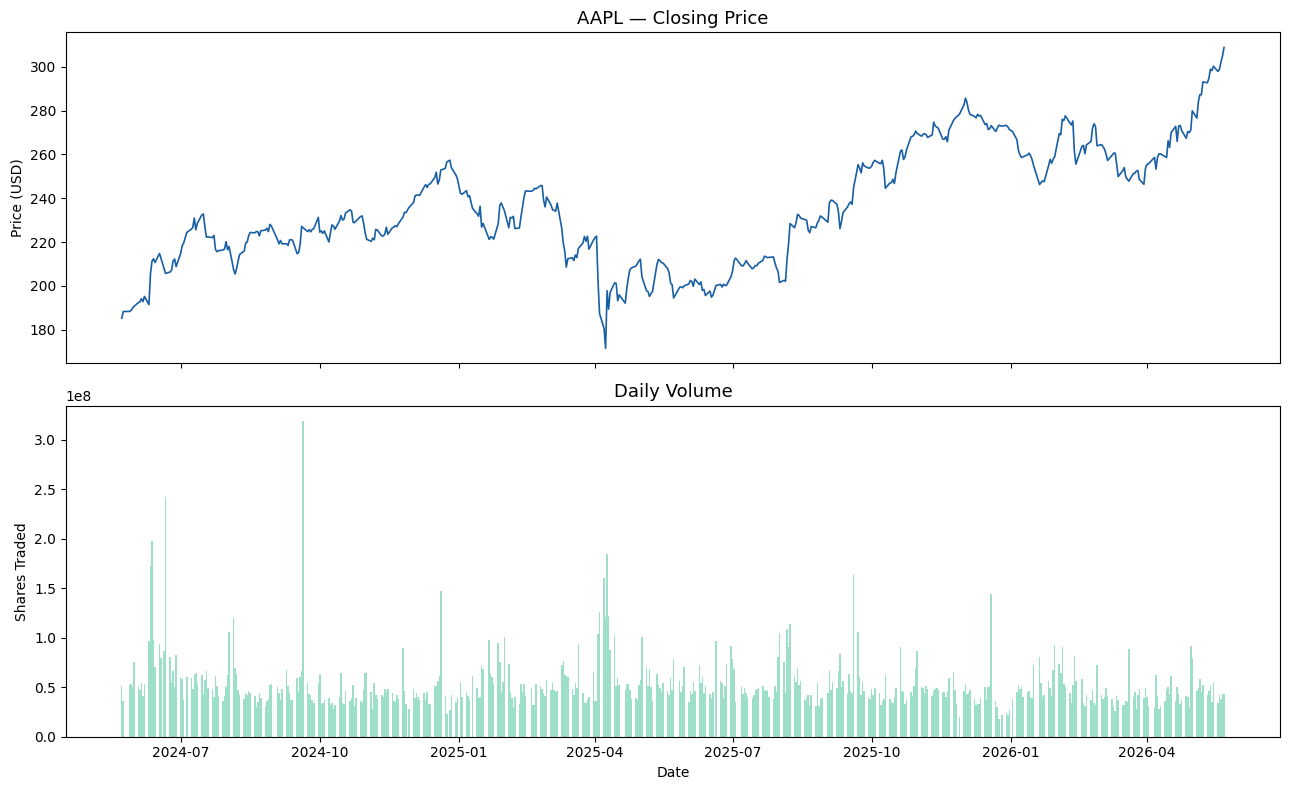

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df['Close'], color='#185FA5', linewidth=1.2)
axes[0].set_title('AAPL — Closing Price', fontsize=13)
axes[0].set_ylabel('Price (USD)')

axes[1].bar(df.index, df['Volume'], color='#5DCAA5', alpha=0.6, width=1)
axes[1].set_title('Daily Volume', fontsize=13)
axes[1].set_ylabel('Shares Traded')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig("./plots/price_and_volume.png", dpi=150)
plt.show()


### What to Notice
Look for large spikes in trading volume. These often occur during important market events or strong price movements.

### 3.3 — Comparing Multiple Stocks (Normalized)


[*********************100%***********************]  3 of 3 completed


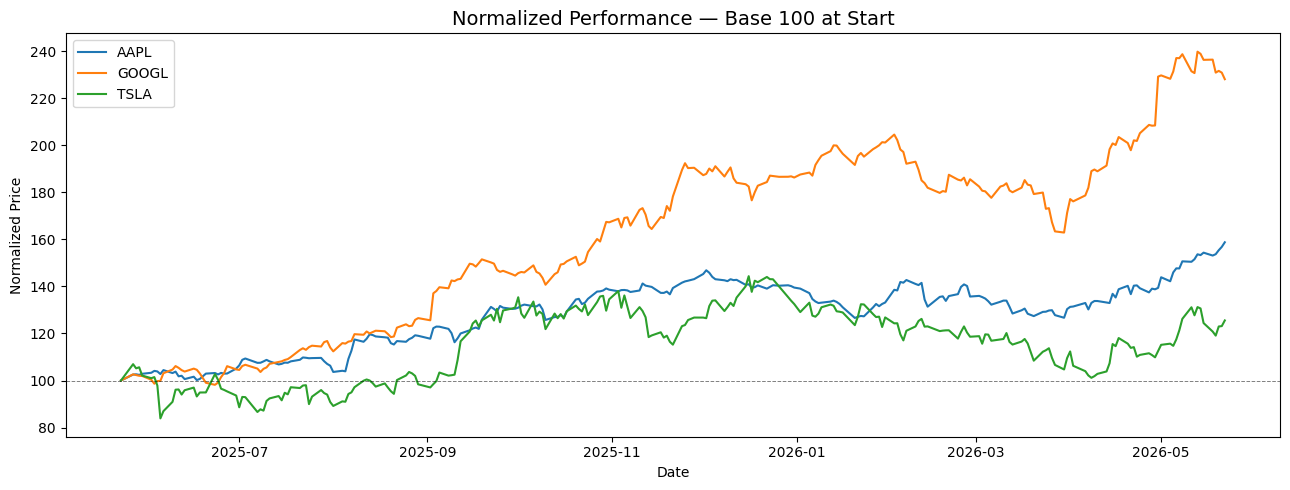

In [41]:
tickers = ["AAPL", "TSLA", "GOOGL"]
raw = yf.download(tickers, period="1y")["Close"]


# Normalize: divide every column by its first value, multiply by 100
# This makes all stocks start at 100 so you compare performance, not price
normalized = raw / raw.iloc[0] * 100

plt.figure(figsize=(13, 5))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

plt.axhline(100, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
plt.title('Normalized Performance — Base 100 at Start', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.tight_layout()
plt.savefig("./plots/multi_stock.png", dpi=150)
plt.show()


### What to Notice
Even though all stocks start at the same normalized value, their growth patterns differ significantly over time. Compare which stock performed best and which was most volatile.

### 3.4 — Moving Averages

A moving average helps smooth stock prices so trends are easier to see.

Instead of looking at one day’s price, we take the average of the last few days.

Examples:
- MA20 → average price of last 20 days
- MA50 → average price of last 50 days

Moving averages help:
- identify trends 📈📉
- reduce noise
- compare short-term vs long-term movement


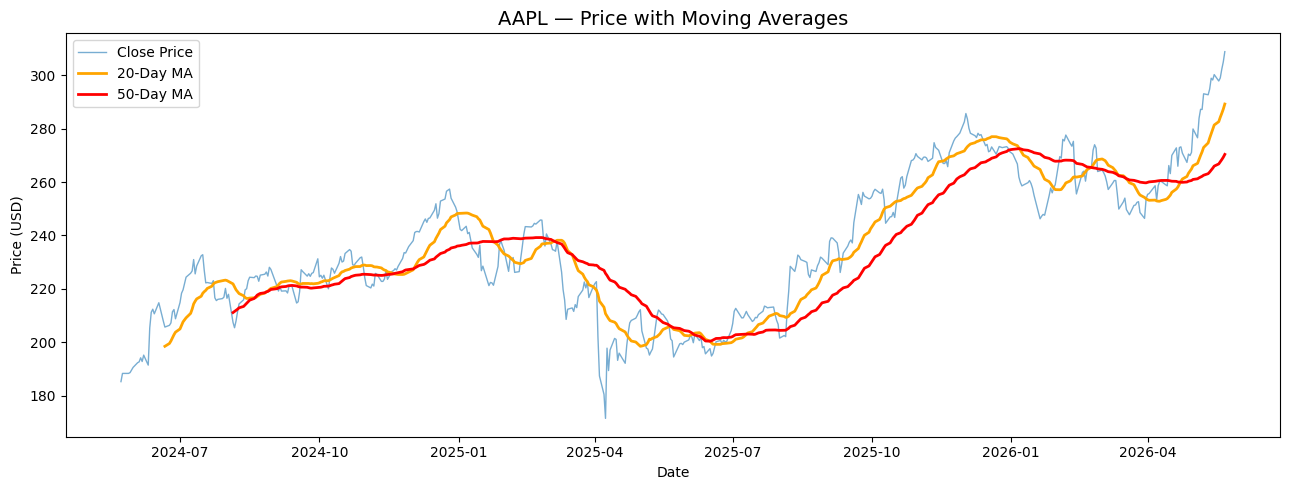

In [42]:
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

plt.figure(figsize=(13, 5))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.6, linewidth=1)
plt.plot(df.index, df['MA20'], label='20-Day MA', linewidth=2, color='orange')
plt.plot(df.index, df['MA50'], label='50-Day MA', linewidth=2, color='red')
plt.title('AAPL — Price with Moving Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig("./plots/moving_averages.png", dpi=150)
plt.show()


> 💡 **Golden Cross:** 20-day MA crosses *above* 50-day MA — bullish signal.
> **Death Cross:** 20-day MA crosses *below* 50-day MA — bearish signal.
> You'll turn these patterns into features in Week 3.


### What to Notice
Observe how the shorter moving average reacts faster to price changes. Look for crossover points between the 20-day and 50-day moving averages.

### 3.5 — Daily Returns Chart
> 💡 **`pct_change()`** = `(today - yesterday) / yesterday`. A value of 0.02 means the stock went up 2% that day.

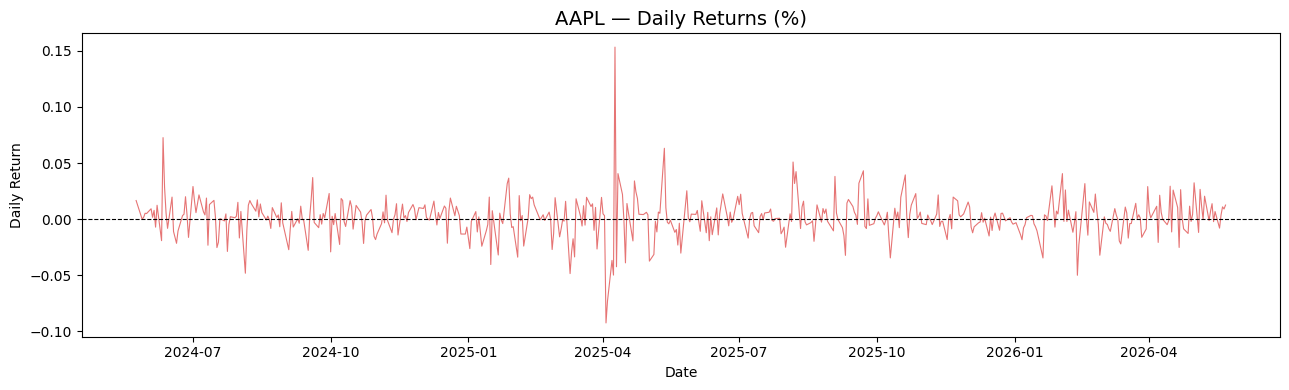

In [43]:
df["Daily_Return"] = df["Close"].pct_change()

plt.figure(figsize=(13, 4))
plt.plot(df.index, df['Daily_Return'], linewidth=0.8, color='#E05252', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('AAPL — Daily Returns (%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.savefig("./plots/daily_returns.png", dpi=150)
plt.show()


### What to Notice
Daily returns fluctuate around zero. Large spikes indicate unusually volatile trading days.



### 🎯 Mini Exercise
Plot the closing price with both moving averages for a stock of your choice. Can you spot a Golden Cross or Death Cross? Write your observation in the cell below.


In [44]:
# Your observation:


## Final Observation Exercise

Review all the graphs above and write 3–5 meaningful observations about the stock’s behavior.

Try to answer questions such as:
- Was the stock generally bullish or bearish?
- When was volatility highest?
- Did volume spikes align with major price movements?
- Was there a Golden Cross or Death Cross?
- Which stock showed the strongest relative performance?



### 📚 Resources
- 🎥 [Matplotlib full tutorial — Corey Schafer (YouTube)](https://www.youtube.com/watch?v=UO98lJQ3QGI)
- 🎥 [Seaborn tutorial — Kimberly Fessel (YouTube)](https://www.youtube.com/watch?v=6GUZXDef2U0)
- 📖 [Matplotlib official gallery](https://matplotlib.org/stable/gallery/index.html)


---
## 4 · Exploratory Data Analysis (EDA)

### Why This Matters
EDA is about asking questions from data and using visualizations to discover patterns before building machine learning models.

### 4.1 — Descriptive Statistics


In [45]:
print(df.describe())


            Close        High         Low        Open        Volume  \
count  501.000000  501.000000  501.000000  501.000000  5.010000e+02   
mean   235.781361  238.110514  233.201224  235.507501  5.287187e+07   
std     26.461423   26.411939   26.443335   26.436300  2.655847e+07   
min    171.513763  188.943288  168.320644  171.046219  1.791060e+07   
25%    215.622177  217.610176  212.776815  214.814992  3.944620e+07   
50%    231.266357  232.586474  228.261629  230.646387  4.650800e+07   
75%    257.292084  258.531784  254.330493  256.550893  5.582420e+07   
max    308.820007  311.399994  305.839996  306.119995  3.186799e+08   

       Daily_Range   OC_Change        MA20        MA50  Daily_Return  
count   501.000000  501.000000  482.000000  452.000000    500.000000  
mean      4.909290    0.129400  235.422693  235.015930      0.001178  
std       2.684684    1.541686   23.776039   22.079857      0.017756  
min       1.536677   -7.648634  198.505460  200.410213     -0.092456  
25%  


- **count** → Number of data values present  
- **mean** → Average value  
- **std (standard deviation)** → Measures how spread out the data is  
- **min** → Smallest value  
- **25% (25 percentile )**   → Value below which 25% of the data lies  ,
- **50% (median, 50 percentile )** → Middle value of the data  50 percentile 
- **75%  (75 percentile )** → Value below which 75% of the data lies  
- **max** → Largest value  


In [46]:
returns = df['Daily_Return'].dropna()   
print(f'Average daily return : {returns.mean()*100}%')
# - **Average daily return** → Average percentage change in stock price per day  

print(f'Std deviation (risk) : {returns.std()*100}%')
# - **Std deviation (risk)** → Measures how volatile the stock is. Higher value means higher risk and bigger price swings.  

print(f'Best single day      : {returns.max()*100}%')
# - **Best single day** → Highest one-day gain in the dataset  

print(f'Worst single day     : {returns.min()*100}%')
# - **Worst single day** → Largest one-day loss in the dataset  

Average daily return : 0.11782615451274665%
Std deviation (risk) : 1.775554638114659%
Best single day      : 15.328843665210435%
Worst single day     : -9.245604966108267%


### 4.2 — Understanding Return distributions


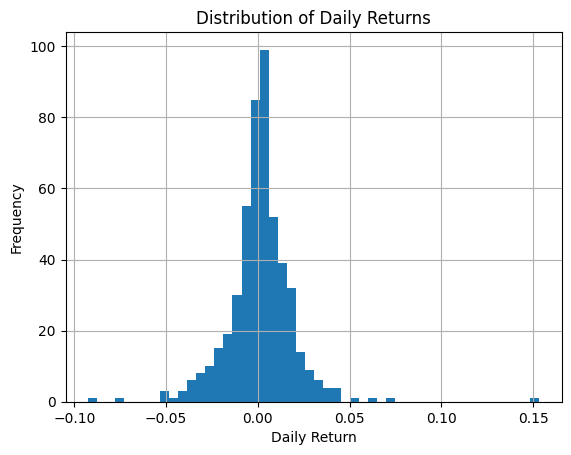

In [47]:
df['Daily_Return'].hist(bins=50)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()


### Observation
Most daily returns are clustered near 0, while very large gains or losses happen less frequently.
This creates a shape that often resembles a “bell curve”, an important concept in statistics and machine learning.

### Learn More — Bell Curve / Normal Distribution

Before moving ahead, spend 5–10 minutes understanding what a normal distribution (bell curve) means:

- https://www.youtube.com/watch?v=rzFX5NWojp0
- https://www.geeksforgeeks.org/maths/normal-distribution

### 4.3 — Correlation Heatmap (Seaborn)

Correlation measures how strongly two variables are related.

Its value ranges from:

- `+1` → strong positive relationship  
  Example : Rainfall and crop yield are positively correlated 
- `0` → no relationship  
  Example: Stock price and today's temperature
- `-1` → strong negative relationship  

Examples:
- If two values increase together, correlation is positive.
- If one increases while the other decreases, correlation is negative.



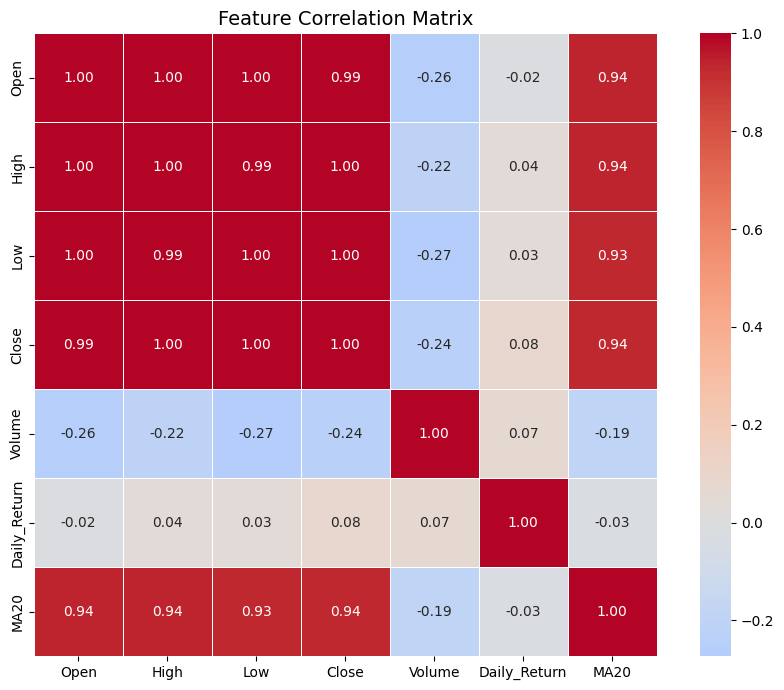

In [48]:
cols = ["Open", "High", "Low", "Close", "Volume", "Daily_Return", "MA20"]
corr = df[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig("./plots/correlation_heatmap.png", dpi=150)
plt.show()


A correlation heatmap is a visual way to compare relationships between multiple features in the dataset.

In this heatmap:
- Red colors → strong positive correlation  
- Blue colors → negative correlation  
- Values close to `1` mean the features move together strongly.


### Why Are Open, High, Low, and Close So Similar?

These values come from the same trading day and represent related price measurements, so they naturally move together very strongly.

### What to Notice

- Open, High, Low, and Close prices are highly positively correlated.
- Volume has a much weaker relationship with price features.
- Daily returns are less correlated because returns fluctuate rapidly day-to-day.
- Strong correlations can help us identify related or redundant features before building ML models.

**Write your observation below:**


In [49]:
# Observation:


### 4.4 Bonus graph 

EDA is not only about plotting standard graphs — it is also about asking interesting questions from data.

Here, we explore whether stock returns show any weekday-based patterns.

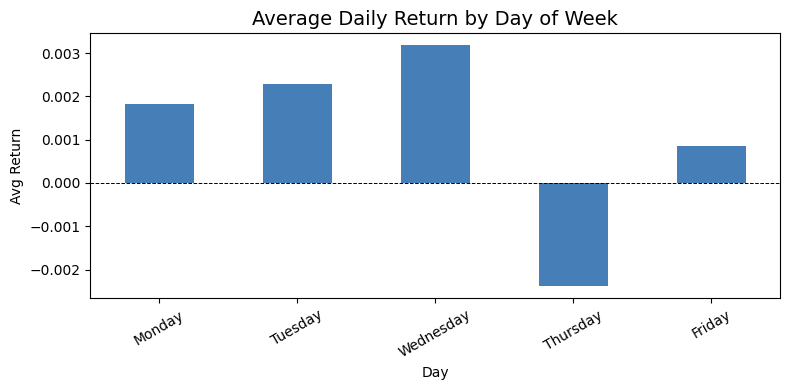

In [50]:
df["Day_of_Week"] = df.index.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
dow_avg = df.groupby('Day_of_Week')['Daily_Return'].mean().reindex(order)

plt.figure(figsize=(8, 4))
dow_avg.plot(kind='bar', color='#185FA5', alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.title('Average Daily Return by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Avg Return')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("./plots/day_of_week.png", dpi=150)
plt.show()


### 📚 Resources
- 🎥 [EDA for beginners — Krish Naik (YouTube)](https://www.youtube.com/watch?v=F-X5O8MGQus)
- 📖 [Seaborn gallery](https://seaborn.pydata.org/examples/index.html)


### 🚀 Bonus Challenge
- Perform the full analysis pipeline on an Indian stock  
      *(RELIANCE.NS, TCS.NS, INFY.NS, etc.)*


# 🎉 Week 2 Summary

In this week, we explored how to clean, visualize, and analyze stock market data using Python.

You learned how to:
- clean and prepare datasets
- visualize stock trends and trading volume
- analyze returns and volatility
- use moving averages
- explore correlations between features
- derive insights using EDA

These concepts form the foundation for feature engineering and machine learning, which we’ll begin in Week 3 🚀

